'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: bf17ab05-0f81-4a92-af6a-1fa78ff7972e)')' thrown while requesting HEAD https://huggingface.co/datasets/nyu-mll/glue/resolve/main/README.md
Retrying in 1s [Retry 1/5].
Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

step=   1 | loss=5.8620 | clean_acc=0.4908 | ood_acc=0.4908 | sensitivity=0.0617
step=  50 | loss=1.7297 | clean_acc=0.5069 | ood_acc=0.4920 | sensitivity=0.0394
step= 100 | loss=0.7477 | clean_acc=0.6422 | ood_acc=0.5872 | sensitivity=0.0312
step= 150 | loss=0.1734 | clean_acc=0.7741 | ood_acc=0.7282 | sensitivity=0.0373
step= 200 | loss=0.2857 | clean_acc=0.8337 | ood_acc=0.7626 | sensitivity=0.0462
step= 250 | loss=0.3241 | clean_acc=0.7741 | ood_acc=0.7190 | sensitivity=0.0399
step= 300 | loss=0.1659 | clean_acc=0.8406 | ood_acc=0.7821 | sensitivity=0.0418
step= 350 | loss=0.1502 | clean_acc=0.8521 | ood_acc=0.7787 | sensitivity=0.0422
step= 400 | loss=0.2066 | clean_acc=0.8360 | ood_acc=0.7408 | sensitivity=0.0451
step= 450 | loss=0.6107 | clean_acc=0.8406 | ood_acc=0.7569 | sensitivity=0.0370
step= 500 | loss=0.3317 | clean_acc=0.8807 | ood_acc=0.8280 | sensitivity=0.0480
step= 550 | loss=0.4726 | clean_acc=0.8750 | ood_acc=0.8085 | sensitivity=0.0555
step= 600 | loss=0.1444 | cl

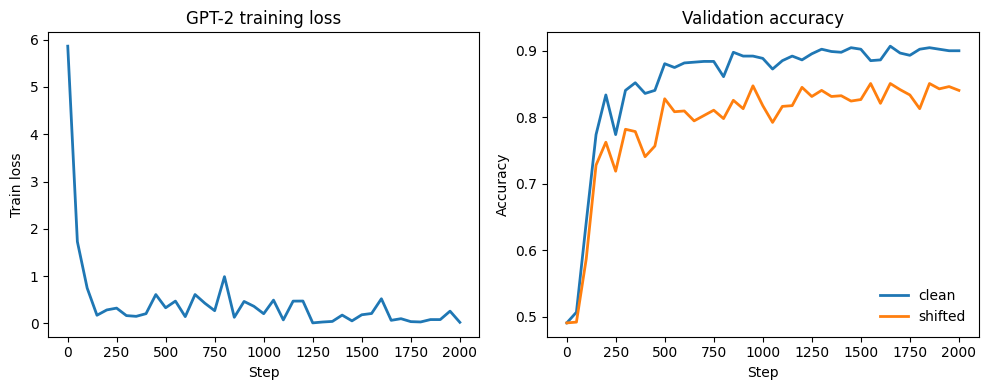

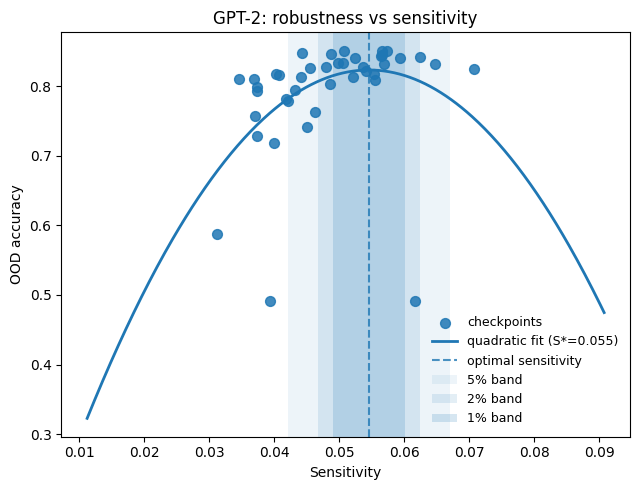

In [4]:
# Minimal GPT-2 experiment: SST-2 fine-tuning + sensitivity/robustness tracking
# Requires: pip install transformers datasets evaluate accelerate torch
#
# What it does:
# 1. Fine-tunes GPT-2 on SST-2 sentiment classification
# 2. Tracks a finite-difference sensitivity surrogate in embedding space
# 3. Evaluates robustness under a simple synthetic shift (random token substitution)
# 4. Fits a quadratic robustness-vs-sensitivity curve and reports S* and overshoot drop
#
# Notes:
# - Uses GPT-2 as a sequence classifier.
# - Sets pad_token = eos_token for batching.
# - Keeps everything in one file / one block.

import math
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def compute_accuracy(preds, labels):
    preds = np.array(preds)
    labels = np.array(labels)
    return (preds == labels).mean()


# -----------------------------
# Config
# -----------------------------
@dataclass
class Config:
    model_name: str = "gpt2"
    max_length: int = 128
    train_batch_size: int = 8
    eval_batch_size: int = 16
    lr: float = 5e-5
    weight_decay: float = 0.01
    epochs: int = 2
    warmup_ratio: float = 0.06
    eps_fd: float = 1e-3
    n_vecs: int = 4
    shift_prob: float = 0.10
    eval_every_steps: int = 50
    max_train_examples: int = 8000
    max_val_examples: int = 1000
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()
set_seed(42)
device = torch.device(cfg.device)

# -----------------------------
# Load dataset and metric
# -----------------------------
raw = load_dataset("glue", "sst2")
if cfg.max_train_examples is not None:
    raw["train"] = raw["train"].shuffle(seed=42).select(range(min(cfg.max_train_examples, len(raw["train"]))))
if cfg.max_val_examples is not None:
    raw["validation"] = raw["validation"].shuffle(seed=42).select(range(min(cfg.max_val_examples, len(raw["validation"]))))

#metric = evaluate.load("glue", "sst2")

# -----------------------------
# Tokenizer and model
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(
    cfg.model_name,
    num_labels=2,
)
model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

# -----------------------------
# Preprocessing
# -----------------------------
def preprocess(batch):
    enc = tokenizer(
        batch["sentence"],
        truncation=True,
        max_length=cfg.max_length,
    )
    enc["labels"] = batch["label"]
    return enc

tokenized = raw.map(preprocess, batched=True, remove_columns=raw["train"].column_names)
collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8 if device.type == "cuda" else None)

train_loader = DataLoader(
    tokenized["train"],
    batch_size=cfg.train_batch_size,
    shuffle=True,
    collate_fn=collator,
)
val_loader = DataLoader(
    tokenized["validation"],
    batch_size=cfg.eval_batch_size,
    shuffle=False,
    collate_fn=collator,
)

# -----------------------------
# Optimizer / scheduler
# -----------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
num_train_steps = cfg.epochs * len(train_loader)
num_warmup_steps = int(cfg.warmup_ratio * num_train_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_train_steps,
)

# -----------------------------
# Sensitivity surrogate
# -----------------------------
@torch.no_grad()
def sensitivity_sigma_mean_fd(
    model,
    batch,
    eps: float = 1e-3,
    n_vecs: int = 4,
) -> float:
    """
    Finite-difference sensitivity surrogate in embedding space.
    Returns mean ||f(x+eps*v)-f(x)|| / eps over random unit directions.
    """
    model.eval()

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    emb = model.transformer.wte(input_ids)  # [B, T, D]
    base_logits = model(inputs_embeds=emb, attention_mask=attention_mask).logits

    vals = []
    for _ in range(n_vecs):
        v = torch.randn_like(emb)
        v = v / (v.norm(dim=-1, keepdim=True) + 1e-12)  # unit norm per token embedding
        pert_logits = model(inputs_embeds=emb + eps * v, attention_mask=attention_mask).logits
        delta = pert_logits - base_logits
        vals.append(delta.norm(dim=-1).mean().item() / eps)

    model.train()
    return float(np.mean(vals))

# -----------------------------
# Synthetic distribution shift
# -----------------------------
def apply_token_substitution_shift(batch, shift_prob: float = 0.10):
    """
    Randomly substitutes non-special, non-padding tokens.
    """
    input_ids = batch["input_ids"].clone()
    attention_mask = batch["attention_mask"]
    B, T = input_ids.shape

    special_ids = {
        tokenizer.pad_token_id,
        tokenizer.eos_token_id,
        tokenizer.bos_token_id,
        tokenizer.unk_token_id,
    }
    special_ids = {x for x in special_ids if x is not None}

    rand_mask = torch.rand_like(input_ids.float()) < shift_prob
    valid_mask = attention_mask.bool()

    for sid in special_ids:
        valid_mask &= input_ids.ne(sid)

    replace_mask = rand_mask & valid_mask
    num_replace = int(replace_mask.sum().item())
    if num_replace > 0:
        input_ids[replace_mask] = torch.randint(
            low=0,
            high=tokenizer.vocab_size,
            size=(num_replace,),
            device=input_ids.device,
        )

    out = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": batch["labels"],
    }
    return out

# -----------------------------
# Evaluation
# -----------------------------
@torch.no_grad()
def evaluate_clean(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        preds = logits.argmax(dim=-1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    model.train()
    return compute_accuracy(all_preds, all_labels)

@torch.no_grad()
def evaluate_shifted(model, loader, shift_prob: float = 0.10):
    model.eval()
    all_preds, all_labels = [], []

    for batch in loader:
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
        shifted = apply_token_substitution_shift(batch, shift_prob=shift_prob)

        logits = model(
            input_ids=shifted["input_ids"],
            attention_mask=shifted["attention_mask"],
        ).logits
        preds = logits.argmax(dim=-1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(shifted["labels"].cpu().tolist())

    model.train()
    return compute_accuracy(all_preds, all_labels)

# -----------------------------
# Training loop with tracking
# -----------------------------
history = {
    "step": [],
    "train_loss": [],
    "clean_acc": [],
    "ood_acc": [],
    "sensitivity": [],
}

global_step = 0
for epoch in range(cfg.epochs):
    for batch in train_loader:
        global_step += 1

        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        loss = outputs.loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        scheduler.step()

        if global_step % cfg.eval_every_steps == 0 or global_step == 1 or global_step == num_train_steps:
            clean_acc = evaluate_clean(model, val_loader)
            ood_acc = evaluate_shifted(model, val_loader, shift_prob=cfg.shift_prob)

            # use one validation batch for sensitivity snapshot
            val_batch = next(iter(val_loader))
            sens = sensitivity_sigma_mean_fd(
                model,
                {k: v.to(device) if torch.is_tensor(v) else v for k, v in val_batch.items()},
                eps=cfg.eps_fd,
                n_vecs=cfg.n_vecs,
            )

            history["step"].append(global_step)
            history["train_loss"].append(float(loss.item()))
            history["clean_acc"].append(float(clean_acc))
            history["ood_acc"].append(float(ood_acc))
            history["sensitivity"].append(float(sens))

            print(
                f"step={global_step:4d} | "
                f"loss={loss.item():.4f} | "
                f"clean_acc={clean_acc:.4f} | "
                f"ood_acc={ood_acc:.4f} | "
                f"sensitivity={sens:.4f}"
            )

# -----------------------------
# Quadratic fit + band stats
# -----------------------------
S = np.array(history["sensitivity"], dtype=float)
R = np.array(history["ood_acc"], dtype=float)

a, b, c = np.polyfit(S, R, 2)
S_star = -b / (2 * a)
R_star = a * S_star**2 + b * S_star + c

def eta_band(a, b, c, eta: float):
    target = (1.0 - eta) * R_star
    # solve a S^2 + b S + c = target
    A, B, C = a, b, c - target
    disc = B * B - 4 * A * C
    if disc < 0:
        return None
    r1 = (-B - math.sqrt(disc)) / (2 * A)
    r2 = (-B + math.sqrt(disc)) / (2 * A)
    return (min(r1, r2), max(r1, r2))

band_1 = eta_band(a, b, c, 0.01)
band_2 = eta_band(a, b, c, 0.02)
band_5 = eta_band(a, b, c, 0.05)

# overshoot drop: compare best observed checkpoint to highest-sensitivity tail
idx_best = np.argmax(R)
S_best = S[idx_best]
R_best = R[idx_best]

sorted_idx = np.argsort(S)
k = max(1, int(0.2 * len(S)))  # top 20% sensitivity as overshoot region
overs_idx = sorted_idx[-k:]
S_over_mean = float(S[overs_idx].mean())
R_over_mean = float(R[overs_idx].mean())

drop_abs = R_best - R_over_mean
drop_pct = 100.0 * drop_abs / (R_best + 1e-12)

print("\n--- Quadratic Fit Summary ---")
print(f"a,b,c = {a:.6f}, {b:.6f}, {c:.6f}")
print(f"S* = {S_star:.6f}")
print(f"R(S*) = {R_star:.6f}")
print(f"band@1% = {band_1}")
print(f"band@2% = {band_2}")
print(f"band@5% = {band_5}")
print(f"S_best = {S_best:.6f}, R_best = {R_best:.6f}")
print(f"S_over_mean = {S_over_mean:.6f}, R_over_mean = {R_over_mean:.6f}")
print(f"Overshoot drop = {drop_pct:.2f}%")

# -----------------------------
# Optional plots
# -----------------------------
try:
    import matplotlib.pyplot as plt

    # Training curves
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["step"], history["train_loss"], linewidth=2)
    plt.xlabel("Step")
    plt.ylabel("Train loss")
    plt.title("GPT-2 training loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["step"], history["clean_acc"], linewidth=2, label="clean")
    plt.plot(history["step"], history["ood_acc"], linewidth=2, label="shifted")
    plt.xlabel("Step")
    plt.ylabel("Accuracy")
    plt.title("Validation accuracy")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # Robustness vs sensitivity
    xgrid = np.linspace(S.min() - 0.02, S.max() + 0.02, 400)
    ygrid = np.maximum(a * xgrid**2 + b * xgrid + c, 0)

    plt.figure(figsize=(6.5, 5))
    plt.scatter(S, R, s=50, alpha=0.85, label="checkpoints")
    plt.plot(xgrid, ygrid, linewidth=2, label=f"quadratic fit (S*={S_star:.3f})")
    plt.axvline(S_star, linestyle="--", linewidth=1.5, alpha=0.8, label="optimal sensitivity")

    if band_5 is not None:
        plt.axvspan(band_5[0], band_5[1], alpha=0.08, label="5% band")
    if band_2 is not None:
        plt.axvspan(band_2[0], band_2[1], alpha=0.12, label="2% band")
    if band_1 is not None:
        plt.axvspan(band_1[0], band_1[1], alpha=0.18, label="1% band")

    plt.xlabel("Sensitivity")
    plt.ylabel("OOD accuracy")
    plt.title("GPT-2: robustness vs sensitivity")
    plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

except ImportError:
    pass

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


step=   1 | loss=5.5049 | task=5.5038 | sens=0.0778 | pen=0.0006 | clean=0.4908 | ood=0.4908 | lr=1.00e-06
step=  50 | loss=2294248.7500 | task=1.4589 | sens=0.0243 | pen=1147123.6250 | clean=0.4908 | ood=0.4920 | lr=3.54e-05
step= 100 | loss=213526.8594 | task=1.0848 | sens=0.0412 | pen=106762.8906 | clean=0.4908 | ood=0.4908 | lr=4.07e-05
step= 150 | loss=129305.0156 | task=1.3978 | sens=0.0213 | pen=64651.8086 | clean=0.4908 | ood=0.4920 | lr=3.84e-05
step= 200 | loss=273665.7500 | task=0.7356 | sens=0.0189 | pen=136832.5000 | clean=0.4908 | ood=0.4908 | lr=3.62e-05
step= 250 | loss=18984.8945 | task=0.8174 | sens=0.0149 | pen=9492.0381 | clean=0.4908 | ood=0.4908 | lr=3.39e-05
step= 300 | loss=110387.0938 | task=0.9848 | sens=0.0147 | pen=55193.0547 | clean=0.4908 | ood=0.4908 | lr=3.16e-05
step= 350 | loss=62500.5117 | task=1.1777 | sens=0.0303 | pen=31249.6680 | clean=0.4908 | ood=0.4908 | lr=2.94e-05
step= 400 | loss=103869.8281 | task=0.9434 | sens=0.0121 | pen=51934.4414 | cle

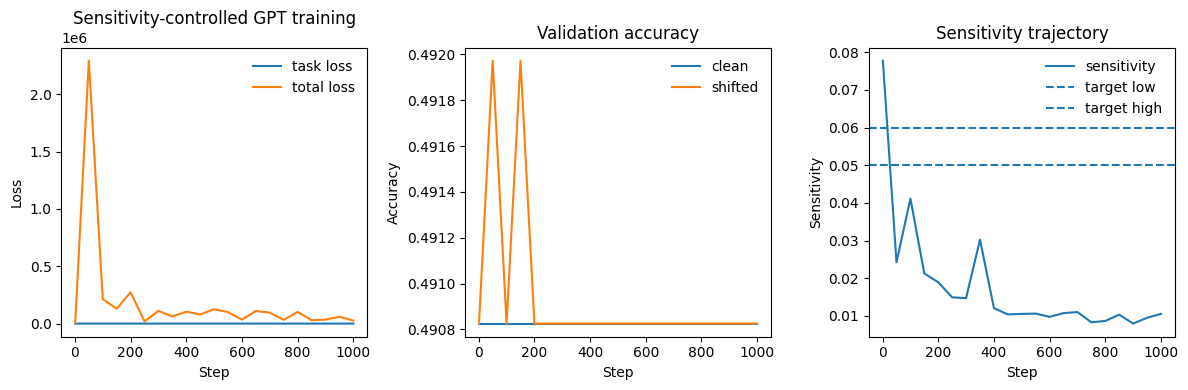

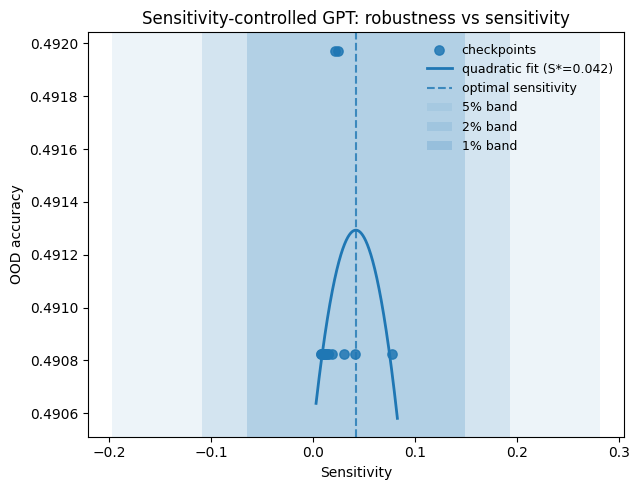

In [5]:
# Sensitivity-controlled training for a small GPT-style sequence classifier
# ------------------------------------------------------------
# Requirements:
#   pip install transformers datasets torch
#
# What this does:
#   1. Fine-tunes GPT-2 on SST-2
#   2. Computes a finite-difference sensitivity surrogate in embedding space
#   3. Adds a band penalty when sensitivity leaves [target_low, target_high]
#   4. Optionally shrinks LR on overshoot
#   5. Tracks clean acc, shifted acc, and sensitivity over training
#
# Suggested paper framing:
#   "We implement a minimal sensitivity-controlled training intervention by
#    penalizing departures from a target sensitivity band."

import math
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# -----------------------------
# Config
# -----------------------------
@dataclass
class Config:
    model_name: str = "gpt2"
    max_length: int = 128
    train_batch_size: int = 8
    eval_batch_size: int = 16
    lr: float = 5e-5
    weight_decay: float = 0.01
    epochs: int = 2
    warmup_ratio: float = 0.06

    # finite-difference sensitivity
    eps_fd: float = 1e-3
    n_vecs_train: int = 1      # keep cheap during training
    n_vecs_eval: int = 4       # use more stable estimate during eval

    # logging / dataset size
    eval_every_steps: int = 50
    max_train_examples: int = 4000
    max_val_examples: int = 1000

    # synthetic OOD shift
    shift_prob: float = 0.10

    # sensitivity-control hyperparameters
    target_low: float = 0.050   # set from prior diagnostic runs if available
    target_high: float = 0.060  # e.g. narrow band around S*
    sens_lambda: float = 2.0    # penalty strength
    overshoot_lr_shrink: float = 0.85   # multiply LR by this on overshoot
    undershoot_lr_boost: float = 1.02   # gentle boost if far below band
    min_lr: float = 1e-6
    max_lr: float = 1e-4

    device: str = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()
device = torch.device(cfg.device)

# -----------------------------
# Dataset
# -----------------------------
raw = load_dataset("glue", "sst2")
raw["train"] = raw["train"].shuffle(seed=42).select(range(min(cfg.max_train_examples, len(raw["train"]))))
raw["validation"] = raw["validation"].shuffle(seed=42).select(range(min(cfg.max_val_examples, len(raw["validation"]))))

tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def preprocess(batch):
    out = tokenizer(batch["sentence"], truncation=True, max_length=cfg.max_length)
    out["labels"] = batch["label"]
    return out

tokenized = raw.map(preprocess, batched=True, remove_columns=raw["train"].column_names)
collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8 if device.type == "cuda" else None)

train_loader = DataLoader(
    tokenized["train"],
    batch_size=cfg.train_batch_size,
    shuffle=True,
    collate_fn=collator,
)
val_loader = DataLoader(
    tokenized["validation"],
    batch_size=cfg.eval_batch_size,
    shuffle=False,
    collate_fn=collator,
)

# -----------------------------
# Model
# -----------------------------
model = AutoModelForSequenceClassification.from_pretrained(cfg.model_name, num_labels=2)
model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
num_train_steps = cfg.epochs * len(train_loader)
num_warmup_steps = int(cfg.warmup_ratio * num_train_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_train_steps,
)

# -----------------------------
# Accuracy utility
# -----------------------------
def compute_accuracy(preds, labels):
    preds = np.array(preds)
    labels = np.array(labels)
    return float((preds == labels).mean())

# -----------------------------
# Synthetic token substitution shift
# -----------------------------
def apply_token_substitution_shift(batch, shift_prob=0.10):
    input_ids = batch["input_ids"].clone()
    attention_mask = batch["attention_mask"]
    labels = batch["labels"]

    special_ids = {
        tokenizer.pad_token_id,
        tokenizer.eos_token_id,
        tokenizer.bos_token_id,
        tokenizer.unk_token_id,
    }
    special_ids = {x for x in special_ids if x is not None}

    rand_mask = (torch.rand_like(input_ids.float()) < shift_prob)
    valid_mask = attention_mask.bool()
    for sid in special_ids:
        valid_mask &= input_ids.ne(sid)

    replace_mask = rand_mask & valid_mask
    n = int(replace_mask.sum().item())
    if n > 0:
        input_ids[replace_mask] = torch.randint(
            low=0,
            high=tokenizer.vocab_size,
            size=(n,),
            device=input_ids.device,
        )

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

# -----------------------------
# Finite-difference sensitivity surrogate
# Differentiable training version: no .item(), no no_grad()
# -----------------------------
def sensitivity_sigma_mean_fd_train(model, batch, eps=1e-3, n_vecs=1):
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]

    emb = model.transformer.wte(input_ids)                 # [B,T,D]
    base_logits = model(inputs_embeds=emb, attention_mask=attention_mask).logits

    vals = []
    for _ in range(n_vecs):
        v = torch.randn_like(emb)
        v = v / (v.norm(dim=-1, keepdim=True) + 1e-12)
        pert_logits = model(inputs_embeds=emb + eps * v, attention_mask=attention_mask).logits
        delta = pert_logits - base_logits
        # mean over batch of logit perturbation norm
        vals.append(delta.norm(dim=-1).mean() / eps)

    return torch.stack(vals).mean()

@torch.no_grad()
def sensitivity_sigma_mean_fd_eval(model, batch, eps=1e-3, n_vecs=4):
    model.eval()
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    emb = model.transformer.wte(input_ids)
    base_logits = model(inputs_embeds=emb, attention_mask=attention_mask).logits

    vals = []
    for _ in range(n_vecs):
        v = torch.randn_like(emb)
        v = v / (v.norm(dim=-1, keepdim=True) + 1e-12)
        pert_logits = model(inputs_embeds=emb + eps * v, attention_mask=attention_mask).logits
        delta = pert_logits - base_logits
        vals.append(delta.norm(dim=-1).mean().item() / eps)

    model.train()
    return float(np.mean(vals))

# -----------------------------
# Band penalty
# Penalize only when outside [target_low, target_high]
# -----------------------------
def band_penalty(sigma, low, high):
    below = F.relu(low - sigma)
    above = F.relu(sigma - high)
    return below.pow(2) + above.pow(2)

# -----------------------------
# Evaluation
# -----------------------------
@torch.no_grad()
def evaluate_clean(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        preds = logits.argmax(dim=-1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    model.train()
    return compute_accuracy(all_preds, all_labels)

@torch.no_grad()
def evaluate_shifted(model, loader, shift_prob=0.10):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
        shifted = apply_token_substitution_shift(batch, shift_prob=shift_prob)
        logits = model(
            input_ids=shifted["input_ids"],
            attention_mask=shifted["attention_mask"],
        ).logits
        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(shifted["labels"].cpu().tolist())
    model.train()
    return compute_accuracy(all_preds, all_labels)

# -----------------------------
# Training with sensitivity control
# -----------------------------
history = {
    "step": [],
    "train_loss": [],
    "task_loss": [],
    "sens": [],
    "sens_penalty": [],
    "clean_acc": [],
    "ood_acc": [],
    "lr": [],
}

global_step = 0
for epoch in range(cfg.epochs):
    for batch in train_loader:
        global_step += 1
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

        # task loss
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        task_loss = outputs.loss

        # sensitivity estimate + band penalty
        sigma = sensitivity_sigma_mean_fd_train(
            model,
            batch,
            eps=cfg.eps_fd,
            n_vecs=cfg.n_vecs_train,
        )
        sens_pen = band_penalty(sigma, cfg.target_low, cfg.target_high)

        # total loss
        loss = task_loss + cfg.sens_lambda * sens_pen

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        scheduler.step()

        # Optional LR adaptation based on overshoot / undershoot
        current_lr = optimizer.param_groups[0]["lr"]
        sigma_val = float(sigma.detach().item())
        if sigma_val > cfg.target_high:
            new_lr = max(cfg.min_lr, current_lr * cfg.overshoot_lr_shrink)
            for pg in optimizer.param_groups:
                pg["lr"] = new_lr
        elif sigma_val < cfg.target_low:
            new_lr = min(cfg.max_lr, current_lr * cfg.undershoot_lr_boost)
            for pg in optimizer.param_groups:
                pg["lr"] = new_lr

        if global_step % cfg.eval_every_steps == 0 or global_step == 1 or global_step == num_train_steps:
            clean_acc = evaluate_clean(model, val_loader)
            ood_acc = evaluate_shifted(model, val_loader, shift_prob=cfg.shift_prob)

            val_batch = next(iter(val_loader))
            sens_eval = sensitivity_sigma_mean_fd_eval(
                model,
                val_batch,
                eps=cfg.eps_fd,
                n_vecs=cfg.n_vecs_eval,
            )

            history["step"].append(global_step)
            history["train_loss"].append(float(loss.item()))
            history["task_loss"].append(float(task_loss.item()))
            history["sens"].append(float(sens_eval))
            history["sens_penalty"].append(float(sens_pen.detach().item()))
            history["clean_acc"].append(float(clean_acc))
            history["ood_acc"].append(float(ood_acc))
            history["lr"].append(float(optimizer.param_groups[0]["lr"]))

            print(
                f"step={global_step:4d} | "
                f"loss={loss.item():.4f} | task={task_loss.item():.4f} | "
                f"sens={sens_eval:.4f} | pen={sens_pen.item():.4f} | "
                f"clean={clean_acc:.4f} | ood={ood_acc:.4f} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e}"
            )

# -----------------------------
# Fit quadratic after training
# -----------------------------
S = np.array(history["sens"], dtype=float)
R = np.array(history["ood_acc"], dtype=float)

a, b, c = np.polyfit(S, R, 2)
S_star = -b / (2 * a)
R_star = a * S_star**2 + b * S_star + c

def eta_band(a, b, c, eta):
    target = (1.0 - eta) * R_star
    A, B, C = a, b, c - target
    disc = B * B - 4 * A * C
    if disc < 0:
        return None
    s1 = (-B - math.sqrt(disc)) / (2 * A)
    s2 = (-B + math.sqrt(disc)) / (2 * A)
    return (min(s1, s2), max(s1, s2))

band_1 = eta_band(a, b, c, 0.01)
band_2 = eta_band(a, b, c, 0.02)
band_5 = eta_band(a, b, c, 0.05)

# overshoot drop: top 20% sensitivity region
idx_best = np.argmax(R)
S_best = float(S[idx_best])
R_best = float(R[idx_best])

sorted_idx = np.argsort(S)
k = max(1, int(0.2 * len(S)))
overs_idx = sorted_idx[-k:]

S_over_mean = float(S[overs_idx].mean())
R_over_mean = float(R[overs_idx].mean())
drop_abs = R_best - R_over_mean
drop_pct = 100.0 * drop_abs / (R_best + 1e-12)

print("\n--- Sensitivity-Controlled Training Summary ---")
print(f"a,b,c = {a:.6f}, {b:.6f}, {c:.6f}")
print(f"S* = {S_star:.6f}")
print(f"R(S*) = {R_star:.6f}")
print(f"band@1% = {band_1}")
print(f"band@2% = {band_2}")
print(f"band@5% = {band_5}")
print(f"S_best = {S_best:.6f}, R_best = {R_best:.6f}")
print(f"S_over_mean = {S_over_mean:.6f}, R_over_mean = {R_over_mean:.6f}")
print(f"Overshoot drop = {drop_pct:.2f}%")

# -----------------------------
# Optional plots
# -----------------------------
try:
    import matplotlib.pyplot as plt

    # loss / accuracy / sensitivity
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.plot(history["step"], history["task_loss"], label="task loss")
    plt.plot(history["step"], history["train_loss"], label="total loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Sensitivity-controlled GPT training")
    plt.legend(frameon=False)

    plt.subplot(1, 3, 2)
    plt.plot(history["step"], history["clean_acc"], label="clean")
    plt.plot(history["step"], history["ood_acc"], label="shifted")
    plt.xlabel("Step")
    plt.ylabel("Accuracy")
    plt.title("Validation accuracy")
    plt.legend(frameon=False)

    plt.subplot(1, 3, 3)
    plt.plot(history["step"], history["sens"], label="sensitivity")
    plt.axhline(cfg.target_low, linestyle="--", label="target low")
    plt.axhline(cfg.target_high, linestyle="--", label="target high")
    plt.xlabel("Step")
    plt.ylabel("Sensitivity")
    plt.title("Sensitivity trajectory")
    plt.legend(frameon=False)

    plt.tight_layout()
    plt.show()

    # robustness vs sensitivity
    xgrid = np.linspace(S.min() - 0.005, S.max() + 0.005, 400)
    ygrid = np.maximum(a * xgrid**2 + b * xgrid + c, 0.0)

    plt.figure(figsize=(6.5, 5))
    plt.scatter(S, R, s=45, alpha=0.85, label="checkpoints")
    plt.plot(xgrid, ygrid, linewidth=2, label=f"quadratic fit (S*={S_star:.3f})")
    plt.axvline(S_star, linestyle="--", linewidth=1.5, alpha=0.8, label="optimal sensitivity")

    if band_5 is not None:
        plt.axvspan(band_5[0], band_5[1], alpha=0.08, label="5% band")
    if band_2 is not None:
        plt.axvspan(band_2[0], band_2[1], alpha=0.12, label="2% band")
    if band_1 is not None:
        plt.axvspan(band_1[0], band_1[1], alpha=0.18, label="1% band")

    plt.xlabel("Sensitivity")
    plt.ylabel("OOD accuracy")
    plt.title("Sensitivity-controlled GPT: robustness vs sensitivity")
    plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

except ImportError:
    pass